In [2]:
#Obtención de la data
#Cargar mas datos (ueba)
from LHC import experiment_CMS
experiment_CMS(num_img=10000, size=64, zip_name="CERN_dataset")

Dataset generado con 10000 imágenes por clase.
Archivo comprimido: CERN_dataset.zip


In [3]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def cargar_datos(zip_path="CERN_dataset.zip", carpeta_salida="CERN_datos"):
    #1. Proceso para descomprimir el archivo ZIP
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(carpeta_salida)
    X = []
    y = []
    #2. Recorrer las carpetas con las imagenes
    for clase in os.listdir(carpeta_salida):
        clase_path = os.path.join(carpeta_salida, clase)
        if os.path.isdir(clase_path):
            for img_name in os.listdir(clase_path):
                img_path = os.path.join(clase_path, img_name)

                # 3. Procedimiento para cargar imagenes en escala de grises
                img = Image.open(img_path).convert("L")
                X.append(np.array(img))
                y.append(clase)  # etiqueta = nombre de la carpeta

    X = np.array(X)
    return X, y

In [4]:
X, y = cargar_datos("CERN_dataset.zip")
print(f"Se cargaron {len(X)} imágenes.")
print(f"Clases encontradas: {set(y)}")
print("Dimensiones de las imágenes:", X.shape)

Se cargaron 60000 imágenes.
Clases encontradas: {'tau', 'quark', 'proton', 'muon', 'neutrino', 'electron'}
Dimensiones de las imágenes: (60000, 64, 64)


In [5]:
X[1]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(64, 64), dtype=uint8)

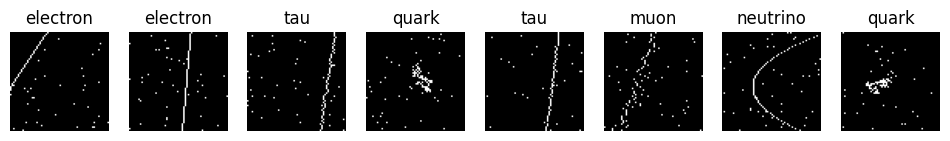

In [6]:
def mostrar_imagenes(X, y, n=6):
    indices = np.random.choice(len(X), n, replace=False)  # elegir imagen aleatoriamente
    plt.figure(figsize=(12, 4))

    for i, idx in enumerate(indices):
        plt.subplot(1, n, i+1)
        plt.imshow(X[idx], cmap="gray")
        plt.title(y[idx])
        plt.axis("off")
    plt.show()

mostrar_imagenes(X, y, n=8)

In [7]:
np.set_printoptions(threshold=np.inf)
print(X[0])
print("Etiqueta:", y[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0 255   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  255   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  255   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 255   0   0   0
    0   0   0   0   0   0   0 255   0   0   0   0   0   0   0   0   0   0
  255   0   0   0   0   0   0   0   0   0   0   0   0   0

## **Clasificación de Trazas de Partículas**

Construya un clasificador supervisado capaz de diferenciar entre distintos tipos de partículas a partir de imágenes de sus trazas. Para ello, se trabajará con el conjunto de datos previamente cargado, organizadas en carpetas según la clase de partícula correspondiente:

*   Electrón
*   Muón
*   Protón
*   Neutrino
*   Quark
*   Tau

Desarrolle un flujo completo de trabajo en aprendizaje automático, desde la carga y exploración de los datos hasta la evaluación de un modelo de clasificación. El ejercicio permitirá comprender los principales pasos de un proyecto de machine learning aplicado al análisis de imágenes.

1. Carga de datos.
2. Exploración inicial: Se deberán mostrar algunas imágenes representativas de cada clase, imprimir las dimensiones de X y y, y analizar la distribución de las clases en el conjunto de datos.
3. Será necesario normalizar los valores de los píxeles en el rango [0, 1], preparar los datos para el modelo y dividirlos en conjuntos de entrenamiento y prueba (por ejemplo, 80% entrenamiento y 20% prueba).
4. Implemente al menos un modelo de clasificación supervisada. Se recomienda iniciar con modelos clásicos como: Regresión Logística y SVM.
5. Evaluación del modelo: El desempeño del clasificador deberá medirse calculando la precisión en el conjunto de prueba. Además, se deberá generar una matriz de confusión para analizar qué clases resultan más fáciles o difíciles de distinguir. Pueden calcular métricas adicionales como la exactitud por clase o las curvas ROC.
6. Discusión y conclusiones: Finalmente, deberá presentar una reflexión sobre los resultados obtenidos, identificando fortalezas y debilidades del clasificador. También deberá proponer mejoras posibles.

In [8]:
# Paso 1: Carga de datos
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from collections import Counter

# Función para cargar imágenes
def load_image_dataset(root_dir, size=(64,64), max_per_class=None):
    X, y = [], []
    classes = sorted(os.listdir(root_dir))
    for cls in classes:
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg'))]
        if max_per_class:
            files = files[:max_per_class]
        for f in files:
            img = imread(os.path.join(cls_path, f))
            if img.ndim == 3:  # convertir a escala de grises si es RGB
                img = img[...,0]
            img_resized = resize(img, size, anti_aliasing=True)
            X.append(img_resized)
            y.append(cls)
    return np.array(X), np.array(y), classes

# Cambia la ruta por la carpeta donde tengas las imágenes
X, y, classes = load_image_dataset("CMS_data", size=(32,32))
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases:", classes)


Shape de X: (60000, 32, 32)
Shape de y: (60000,)
Clases: ['electron', 'muon', 'neutrino', 'proton', 'quark', 'tau']


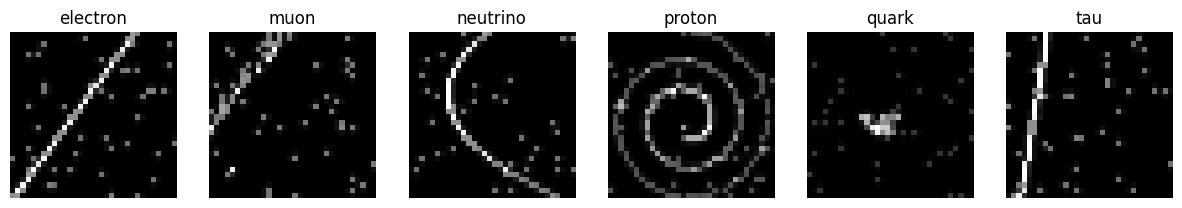

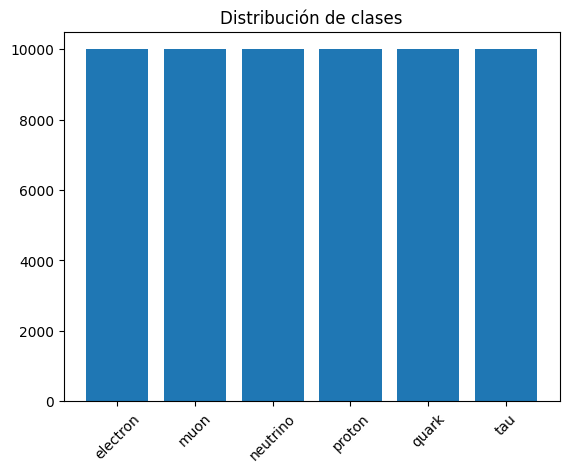

In [11]:
# Paso 2: Exploración inicial
# Mostrar algunas imágenes representativas por clase
fig, axes = plt.subplots(1, len(classes), figsize=(15,4))
for i, cls in enumerate(classes):
    idx = np.where(y == cls)[0][0]  # primer ejemplo de esa clase
    axes[i].imshow(X[idx], cmap="gray")
    axes[i].set_title(cls)
    axes[i].axis("off")
plt.show()

# Distribución de clases
conteo = Counter(y)
plt.bar(conteo.keys(), conteo.values())
plt.xticks(rotation=45)
plt.title("Distribución de clases")
plt.show()

In [12]:
# Paso 3: Normalización y división de datos
# Normalizar al rango [0,1]
X = X / X.max()

# Aplanar imágenes para modelos clásicos
X_flat = X.reshape(len(X), -1)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (48000, 1024) Test: (12000, 1024)


In [13]:
# Paso 4a: Modelo clásico - Regresión Logística
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000, solver="lbfgs", multi_class="auto")
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_lr))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_lr))


/home/debian12/Documentos/UD/Mineria_de_Datos/MD/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy Regresión Logística: 0.6508333333333334

Reporte de clasificación:
               precision    recall  f1-score   support

    electron       0.37      0.31      0.34      2000
        muon       0.39      0.33      0.35      2000
    neutrino       0.61      0.71      0.66      2000
      proton       1.00      1.00      1.00      2000
       quark       1.00      0.98      0.99      2000
         tau       0.49      0.57      0.53      2000

    accuracy                           0.65     12000
   macro avg       0.64      0.65      0.64     12000
weighted avg       0.64      0.65      0.64     12000



In [14]:
# Paso 4b: Modelo clásico - SVM
from sklearn.svm import SVC

svm_clf = SVC(kernel="rbf", C=10, gamma="scale")
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)

print("Accuracy SVM:", accuracy_score(y_test, y_pred_svm))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_svm))


Accuracy SVM: 0.9615833333333333

Reporte de clasificación:
               precision    recall  f1-score   support

    electron       0.93      0.84      0.88      2000
        muon       0.97      0.96      0.97      2000
    neutrino       1.00      1.00      1.00      2000
      proton       1.00      1.00      1.00      2000
       quark       1.00      1.00      1.00      2000
         tau       0.88      0.97      0.92      2000

    accuracy                           0.96     12000
   macro avg       0.96      0.96      0.96     12000
weighted avg       0.96      0.96      0.96     12000



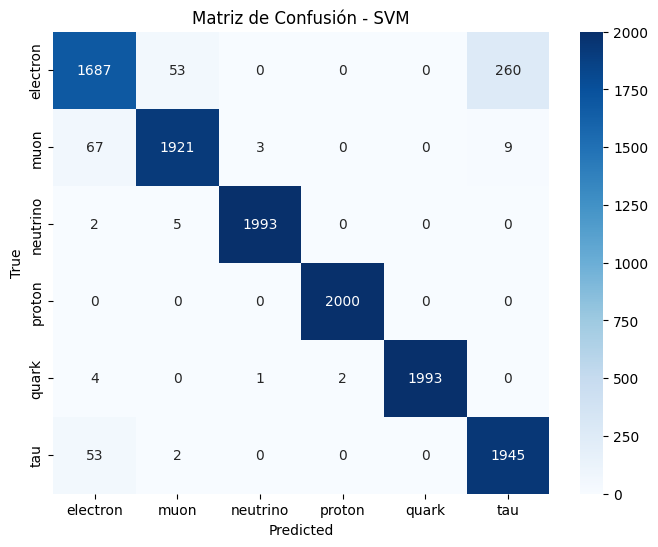

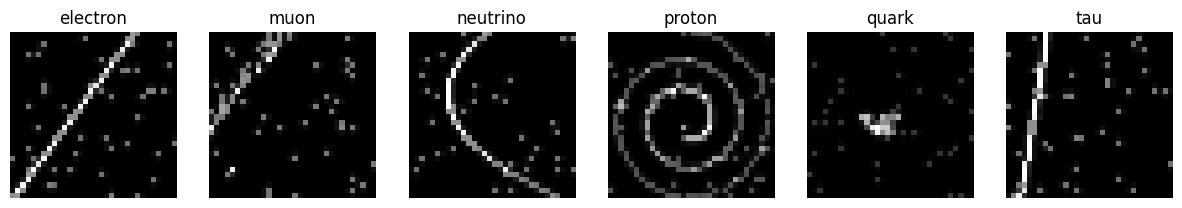

In [18]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm, labels=classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Matriz de Confusión - SVM")
plt.show()

fig, axes = plt.subplots(1, len(classes), figsize=(15,4))
for i, cls in enumerate(classes):
    idx = np.where(y == cls)[0][0]  # primer ejemplo de esa clase
    axes[i].imshow(X[idx], cmap="gray")
    axes[i].set_title(cls)
    axes[i].axis("off")
plt.show()


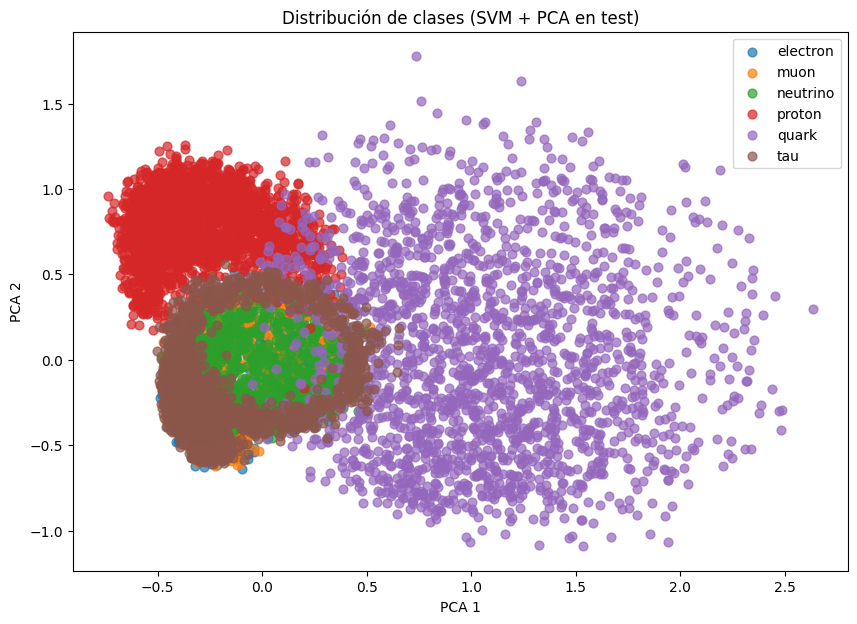

In [17]:
from sklearn.decomposition import PCA

# Reducimos datos de test a 2D para visualizar
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test)

# Predicciones del modelo entrenado
y_pred = svm_clf.predict(X_test)

# Graficamos: puntos coloreados por la clase predicha
plt.figure(figsize=(10,7))
for i, cls in enumerate(classes):
    idx = np.where(y_pred == cls)
    plt.scatter(X_test_pca[idx, 0], X_test_pca[idx, 1], label=cls, s=40, alpha=0.7)

plt.title("Distribución de clases (SVM + PCA en test)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()



Forma original (PCA): (48000, 2)
Forma transformada (Poly): (48000, 6)


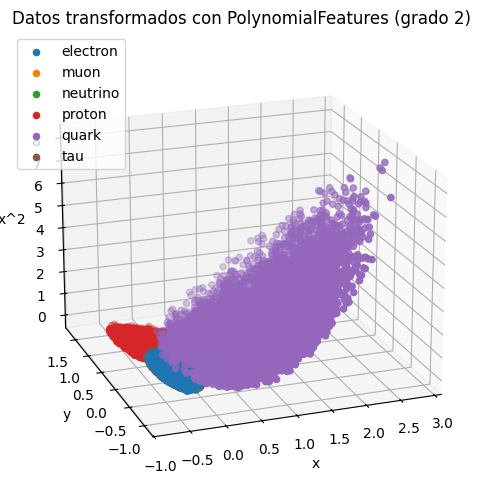

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from mpl_toolkits.mplot3d import Axes3D

# Tomamos los datos reducidos a 2D con PCA
X_train_pca = pca.fit_transform(X_train)

# Aplicamos una transformación polinómica de grado 2
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_pca)

print("Forma original (PCA):", X_train_pca.shape)
print("Forma transformada (Poly):", X_train_poly.shape)

# Visualizamos en 3D con solo las 3 primeras features
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

for i, cls in enumerate(classes):
    idx = np.where(y_train == cls)
    ax.scatter(X_train_poly[idx,1],   # componente 1
               X_train_poly[idx,2],   # componente 2
               X_train_poly[idx,3],   # componente 3 (ej. x^2)
               label=cls, s=20)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("x^2")
plt.title("Datos transformados con PolynomialFeatures (grado 2)")
plt.legend()
ax.view_init(elev=20, azim=250)
plt.show()


In [1]:
from sklearn.metrics import classification_report
import pandas as pd

# --- Logistic Regression ---
report_lr = classification_report(y_test, y_pred_lr, output_dict=True, target_names=classes)
df_lr = pd.DataFrame(report_lr).transpose()

plt.figure(figsize=(8,5))
df_lr.loc[classes, "precision"].plot(kind="bar", color="skyblue")
plt.title("Precisión por clase - Regresión Logística")
plt.ylabel("Precisión")
plt.ylim(0,1)
plt.show()

# --- SVM ---
report_svm = classification_report(y_test, y_pred_svm, output_dict=True, target_names=classes)
df_svm = pd.DataFrame(report_svm).transpose()

plt.figure(figsize=(8,5))
df_svm.loc[classes, "precision"].plot(kind="bar", color="salmon")
plt.title("Precisión por clase - SVM")
plt.ylabel("Precisión")
plt.ylim(0,1)
plt.show()


NameError: name 'y_test' is not defined

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

# Binarizar las etiquetas (necesario para ROC multiclase)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# --- Regresión Logística ---
clf_lr = OneVsRestClassifier(LogisticRegression(max_iter=2000, solver="lbfgs"))
clf_lr.fit(X_train, y_train)
y_score_lr = clf_lr.decision_function(X_test)

# --- SVM ---
clf_svm = OneVsRestClassifier(SVC(kernel="rbf", C=10, gamma="scale", probability=True))
clf_svm.fit(X_train, y_train)
y_score_svm = clf_svm.decision_function(X_test)

# Función para graficar ROC
def plot_multiclass_roc(y_test_bin, y_score, classes, title):
    plt.figure(figsize=(8,6))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")
    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

# Graficar ROC para ambos modelos
plot_multiclass_roc(y_test_bin, y_score_lr, classes, "Curvas ROC - Regresión Logística")
plot_multiclass_roc(y_test_bin, y_score_svm, classes, "Curvas ROC - SVM")
